# **Tutorial 2** - Parameter tuning on DYNAP-SE1

### Guidelines for setting up the parameters on the Dynap-SE.

*Overall goals*
1. Tune the parameters of the neuron and synapse circuits to respond to their input in a biologically plausible way.
2. Find bias settings that do not make neurons fire spontaneously in absence of input.
3. Set the synaptic weight and threshold parameters so that the neuron responds with a gain (output spikes / input spikes) of less than 1 (e.g., 0.10  or 0.3) when stimulating a single synapse.
4. **TODO:** Set the synaptic weights of multiple neuron groups in a small Excitatory-Inhibitory network


## **Procedure**
Start by tuning\
**(i)** the **neuron's parameters**, then\
**(ii)** the **synapse's parameters** and finally\
**(iii)** look at out how to configure a network and **set the weights**

**TODO: Add slide with all parameters**

## **Setting parameters in `linear` format**

As mentioned in **`Tutorial 1`**, the parameters on DYNAP-SE1 can be set in 3 formats (`linear`, `tuple` or `index`), where `linear` is proportional to the *biasing current* generated by the Bias Generator, while the `tuple` is the pair of values that select the corresponding registers of the Bias Generator circuit, and `index` is the index in a lookup table that maps `linear` and `tuple` together, giving direct access to all *valid* values.

In this tutorial, we will be most interested in keeping ratios between specific *biasing currents*, so we will be using the `linear` parameter format a lot.

> Note that while we would like to keep perfect ratios, the actual `linear` value set on the chip will always be rounded up or down to the closest valid `tuple`.

**TODO: Add the slide illustrating the bias scaling** 

### **0. Connect to the chip**

In [3]:
import samna
import samna.dynapse1 as dyn1

import sys
sys.path.append("..")


from dynapse1constants import *

import dynapse1utils as ut
import netgen as n
from netgen import Neuron
import time
import numpy as np

from tools.notebook_gui import make_parameter_slider_box

import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
# open without GUI (for board connected to the remote machine)
model, _ = ut.open_dynapse1(gui=False, select_device=False)

[0]:  Bus 1 Device 5 Dynapse1DevKit serial_number 00000002
Selected device: 00000002
Sender port: tcp://0.0.0.0:33371
Receiver port: tcp://0.0.0.0:55407
Opened device name: Dynapse1DevKit
SamnaNode ID: 1
PythonNode ID: 2
0 Dynapse1Wrapper created! libcaer init...
Clearing chip 0... DONE.
Clearing chip 1... DONE.
Clearing chip 2... DONE.
Clearing chip 3... DONE.


In [ ]:
ut.open_gui(model)

Visualizer start command:  /home/dzenn/anaconda3/envs/dynapse1/bin/python -c "import samna, samnagui; samnagui.runVisualizer(0.75, 0.75,         'tcp://0.0.0.0:36013', 'tcp://0.0.0.0:49503', 3)"


(<Thread(Thread-4, started 125955611817664)>, 'tcp://0.0.0.0:97570')

### Connect a **Tuning Companion** to a core

**`DYNAP-SE Tuning Companion`** is a helper class for tuning the DYNAP-SE1 parameters.

It simplifies stimulation of the neuron and synapse circuits and response analysis.

Specifically, the Tuning Companion is able to analyse the waveforms coming from an externally connected oscilloscope.

---

One instance of **`DYNAP-SE Tuning Companion`** connects to one core of the board.

Let's connect to **Core 2** of **Chip 1** for this tutorial.

In [5]:
from tools.dynapse_tuning_companion import DynapseTuningCompanion
import netgen

net_gen = netgen.NetworkGenerator()
DTC = DynapseTuningCompanion(model, chip_id=1, core_id=2, net_gen=net_gen)


### **Preparation**

1. **Switch off all synapses** so that they do not leak into the neurons by setting leaks to the maximum value and gains to zero:
   - Set `ampa_tau` = 1811, `nmda_tau` = 1811, `gaba_a_tau` = 1811, `gaba_b_tau` = 1811 (`index` format)
   - Set `ampa_gain` = 0, `nmda_gain` = 0, `gaba_a_gain` = 0, `gaba_b_gain` = 0


> This can be done with **`DTC.disable_synapses()`**, or importing the parameter file `/parameters/core_state_silent_synapses.txt` for the core


2. **Switch off the spike frequency adaptation**:
   - Set `ahp_tau` = 1811, `ahp_w` = 0, `ahp_gain` = 0

3. **Switch off all neurons** (no DC, max leak):
   - Set `dc` = 0, `tau1` = 1811, `tau2` = 1811

> This can be done with **`DTC.set_state_measure_neuron_tau()`** which sets all of the parameters except `tau1` so that the neuron time constant 1 can be observed in isolation



In [6]:
# disable synapses
DTC.disable_synapses()

# disable adaptation, DC and set neuron gain to 0
DTC.set_state_measure_neuron_tau()

# Disable the Tau1 leak
ut.set_neuron_tau1(model, chip_id=1, core_id=2, bias_value=1811, bias_format='index')

To monitor neurons of **Core 2** of **Chip 1**, connect the oscilloscope to the corresponding connector of the board:

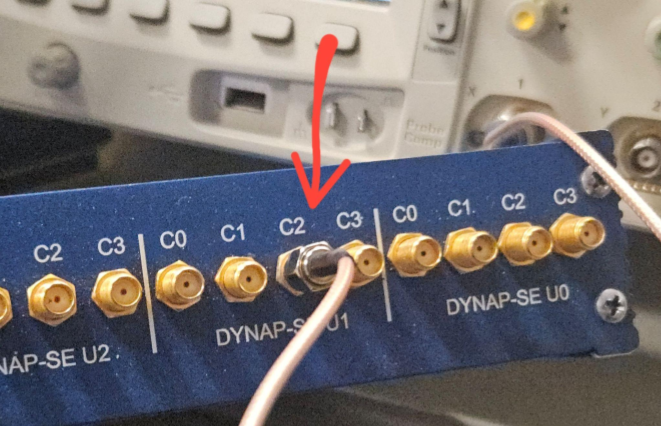

Connect to the oscilloscope via **USB** or **LAN** (refer to the oscilloscope submodule ReadMe to establish the connection)

In [7]:
DTC.connect_pyscope()

Identification string 'AGILENT TECHNOLOGIES,DSO6054A,MY44002200,06.16.0001
'
Timeout set to 15 s.
Init successful


Select the neuron of the core we are going to monitor

In [8]:
DTC.monitor_neuron(100)

## **Parameters Neuron**

### **1. Neuron time constant**

Instantiate a slider to have an easy access to `tau1` parameter of the neuron

In [9]:
make_parameter_slider_box(model, ['C1c2:tau1'], "Tuning Tau 1")

Let's see if we can observe our square DC pulses on the oscilloscope.

If `tau1` remains at max value, we will likely not see anything as the leak is too strong to generate any $V_{mem}$ increase.

Lower `tau1` to around **1400** and use the function below to generate the DC steps (square pulses using the DC parameter of the set period and for the set duration).

Make sure to set the amplitude of the pulses (using the `bias_max_index` argument) such that the neuron never spikes.

In [10]:
DTC.dc_steps(period_s=0.2, duration_s=2, bias_max_index=1400)

On the oscilloscope screen we should see something like this (adjust the oscilloscope vertical and horizontal scale if needed):

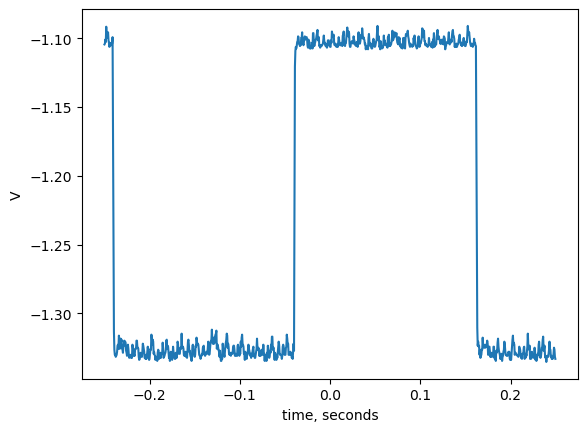

---

**Task:** Start lowering the `tau1` value and look at decay of $V_{mem}$ in oscilloscope. The time constant is roughly 2/3 * of the time it takes for Vmem to decay.

Tune the `tau1` parameter such that the time constant is around between 20 and 40ms.

Save that value of `tau1`.

---

Additionally, the `Tuning Companion` can attempt to extract the time constant from the recorded trace automatically, although the fitting if the trace is not very precise.

In [14]:
wf, time_constant_s = DTC.get_neuron_time_constant(neuron_id=100,
                                                   channel_id=1,
                                                   dc_step_max_index=1200,
                                                   debug_plot=True,
                                                   debug=True)
print(time_constant_s)

Starting waveform recording...
DC steps...
Done.
Recording stopped. Starting waveform retrival...
Waveform capture complete, checking if the neuron spiked...
Spikes recorded: 4752
Spike capture complete
Neuron 100 spikes, unable to measure the time constant!
nan



### **2. Neuron `gain` parameter**
Set `gain` to 2x or at most 3x the `tau1` values found.

To do that, *get* the `tau1` parameter in `linear` format and apply the multiplied value as the `gain` parameter.

In [15]:
# get the current tau1 parameter
tau1_linear = ut.get_neuron_tau1(model, chip_id=1, core_id=2, bias_format='linear')

# calculate the intended linear value of the gain and convert it to int
gain_linear = int(tau1_linear*2.5)

# set the new value (it will automatically rounded to the nearest (coarse, fine) tuple value)
ut.set_neuron_gain(model, chip_id=1, core_id=2, bias_value=gain_linear, bias_format='linear')

# this is to just check what we've set:
print("tau1_linear = ", tau1_linear)
print("gain_linear = ", gain_linear)
print("actual gain_linear = ", ut.get_neuron_gain(model, chip_id=1, core_id=2, bias_format='linear'))


tau1_linear =  47592
gain_linear =  118980
actual gain_linear =  119804


Note that you can also simply enable the checkbox to keep this ratio when using the slider:

In [17]:
make_parameter_slider_box(model, ['C1c2:tau1', 'C1c2:gain'], "Clamping neuron gain example")


### **3. Neuron refractory period**

- Inject a large DC current to make the neuron fire at a high firing rate.

- Set the `rfr` parameter such that the refractory period is 2-3ms using the oscilloscope (adjust the trigger if necessary to stabilize the waveform in the center of the view)

> **Note:** Larger values set faster refractory period

Let's create to sliders to control these two parameters:

In [18]:
bias_tags_rfr_tuning = ["C1c2:dc",
                        "C1c2:rfr"]

make_parameter_slider_box(model, bias_tags_rfr_tuning, "Tuning refractory period")

We can use `instant_plot` option to of the `PyScope` to capture the waveform.

In [ ]:
DTC.scope.get_waveform(1, instant_plot=True)

Additionally, try the `Tuning Companion` function to extract the refractory period from the waveform

In [19]:
DTC.get_rfr_period(neuron_id=100, channel_id=1, instant_plot=True)

100

### **4. Synapse weights, time constants and gain parameters**

a. `NPDPIx_TAU_y_P` where x is E (excitatory) or I (inhibitory) and y is F (fast) or S (slow)\
b. TAU determines the strength of the leak. Small values correspond to a long synaptic time constant\
c. For slow synapses small values are desirable (coarse value between 0 and 3). However if they are too slow, current will leak to the neurons, causing spontaneous firing\
d. The time constant of the fast synapse should be around 10ms and the time constant of the slow synapse should be as large as possible, around 100ms.\

Either:
e. Calculate the synapses time constant parameters as described above in *Neuron time constant bias* and adjust the values for the synapses' smaller capacitors.\

or:
e. To find the synapses's time constant:\
   Set `IF_TAUx_N` of the tested core to a high value so that the neuron directly follows the synaptic input.\
   Use the spike generator to apply input spikes through the synapses to the neuron.\
   Look at decay of Vmem in oscilloscope. The neuron's Vmem directly follow the synapse now. Hence, the synapses time constant is roughly 2/3 * of the time it takes for Vmem to decay.


In [20]:
DTC.connect_spikegen()
DTC.set_spikegen_rate(rate_hz=20)

Spikegen connected to C1c2
New configuration applied to DYNAP-SE1!





### 5.) Synapses threshold bias
a. Set `NPDPIx_THR_y_P` (synapses, x is I or E, y is F or S) to 2x or at most 3x the TAU values found.
b. THR corresponds to an input gain


It might be necessary to iterate over these steps several times. The goal is that there is no spontaneous firing of neurons anymore, while still keeping the TAUs low. 
If there are some neurons that continue firing spontaneously, they can be silenced by assigning them the second TAU bias instead of the first and setting this bias very high. Those neurons need to be selected manually.


In [31]:
DTC.show_synapse_parameter_controls('ampa')

In [69]:
sliders = DTC.show_synapse_parameter_controls('ampa')

In [33]:
bias_tags = ["C0c3:tau1",
             "C0c3:gain",
             "C0c3:gaba_a_gain",
             "C0c2:ampa_tau",
             "C0c2:ampa_gain",
             "C0c3:nmda_gain"]

make_parameter_slider_box(model, bias_tags)

In [50]:
import importlib
import tools.notebook_gui
import tools.dynapse_tuning_companion

importlib.reload(tools.notebook_gui)
importlib.reload(tools.dynapse_tuning_companion)

from tools.notebook_gui import make_parameter_slider_box


### 6.) Weights and pulse width parameters
  `PULSE_PWLK_P`, `PS_WEIGHT_xxx_y` (xxx is EXC or INH, y is F or S)
  - Monitor the spike response of single neurons for different synapse types
    - Start with slow excitatory synapses
    - Choose neurons that are not at the array boundaries
  - Send about 100Hz-1kHz input spikes
  - Balance weight and pulse width.
    - High weights and small pulse width: less mismatch (and vice versa)
    - Pulse width is global for all synapse types, so set is only once and then adapt parameters for each synapse type
    - Weights for fast synapses will probably be about 10 times smaller than for slow ones
  - For inhibitory synapse also send input via an excitatory synapse and observe how the inhibitory input affects the neuron response




### 7.) Set up your nework
  - Observe activities, apply fine tuning where necessary


## Advanced stages

### 8.) Adaptation
  - Negative self-feedback to each neuron, for short-term depression
  - `IF_AHW_P`: feedback weight
  - `IF_AHTAU_N`, `IF_AHTHR_N`: correspond to  TAU and THR
  - `IF_CASC_N` sets an upper limit for effect of the negative feedback. If you want to use adaptation, make sure this is large enough (coarse value about 5 or higher)







### 9.) NMDA
  `IF_NMDA_N` 
  - Slow excitatory synapses only have an effect on the neuron potential if this potential is above some threshod value that is set with `IF_NMDA_N`. Therefore, if this bias is non-zero, some other form of input (fast synapses) is needed to bring the neuron potential above this threshold. 
  - This may be used to introduce “phase transitions” in the network. 
  - The exact relation between the bias and the resulting threshold value is not known. Bias needs to be set manually, while monitoring how the neuron responds to inputs.
  - Has not been studied in much detail, so far.



  TBA: Add gain usage intuition. Add network balancing intuition.

In [ ]:
ut.close_dynapse1(store, device_name, gui_process)